In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import shutil

base_path = "/content/drive/MyDrive/Road_Damage_Project/data"
images_path = os.path.join(base_path, "images")
labels_path = os.path.join(base_path, "labels")

output_path = "/content/drive/MyDrive/Road_Damage_Project/dataset"

class_names = {
    0: "pothole",
    1: "crack",
    2: "manhole"
}

# Create class folders
for class_name in class_names.values():
    os.makedirs(os.path.join(output_path, class_name), exist_ok=True)

print("Folders created ✅")

Folders created ✅


In [ ]:
for label_file in os.listdir(labels_path):
    if label_file.endswith(".txt"):
        label_path = os.path.join(labels_path, label_file)

        with open(label_path, "r") as f:
            lines = f.readlines()

        if len(lines) == 0:
            continue

        # Take first object's class
        class_id = int(lines[0].split()[0])

        image_name = label_file.replace(".txt", ".jpg")
        image_path = os.path.join(images_path, image_name)

        if os.path.exists(image_path):
            shutil.copy(image_path,
                        os.path.join(output_path,
                                     class_names[class_id],
                                     image_name))

print("Conversion Done ✅")

Conversion Done ✅


In [ ]:
 for class_name in class_names.values():
    class_folder = os.path.join(output_path, class_name)
    print(class_name, ":", len(os.listdir(class_folder)))

pothole : 466
crack : 1002
manhole : 541


In [ ]:


import os
import shutil
import random

base_dataset = "/content/drive/MyDrive/Road_Damage_Project/dataset"

train_dir = base_dataset + "/train"
val_dir = base_dataset + "/val"
test_dir = base_dataset + "/test"

class_names = ["pothole", "crack", "manhole"]

# Create split folders
for split in [train_dir, val_dir, test_dir]:
    for class_name in class_names:
        os.makedirs(os.path.join(split, class_name), exist_ok=True)

# Split data
for class_name in class_names:
    images = os.listdir(os.path.join(base_dataset, class_name))
    random.shuffle(images)

    train_split = int(0.7 * len(images))
    val_split = int(0.85 * len(images))

    for img in images[:train_split]:
        shutil.copy(os.path.join(base_dataset, class_name, img),
                    os.path.join(train_dir, class_name, img))

    for img in images[train_split:val_split]:
        shutil.copy(os.path.join(base_dataset, class_name, img),
                    os.path.join(val_dir, class_name, img))

    for img in images[val_split:]:
        shutil.copy(os.path.join(base_dataset, class_name, img),
                    os.path.join(test_dir, class_name, img))

print("Split completed ✅")

Split completed ✅


In [ ]:
for split in ["train", "val", "test"]:
    print("\n", split.upper())
    for class_name in class_names:
        folder = os.path.join(base_dataset, split, class_name)
        print(class_name, ":", len(os.listdir(folder)))


 TRAIN
pothole : 465
crack : 994
manhole : 531

 VAL
pothole : 256
crack : 393
manhole : 212

 TEST
pothole : 261
crack : 383
manhole : 210


In [ ]:
import tensorflow as tf
tf.test.gpu_device_name()

''

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

base_dataset = "/content/drive/MyDrive/Road_Damage_Project/dataset"

train_dir = base_dataset + "/train"
val_dir = base_dataset + "/val"
test_dir = base_dataset + "/test"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_generator = val_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 1990 images belonging to 3 classes.
Found 861 images belonging to 3 classes.
Found 854 images belonging to 3 classes.


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(0.6673373574782026), 1: np.float64(1.2492153170119271), 2: np.float64(1.4265232974910393)}


In [ ]:
print(train_generator.class_indices)

{'crack': 0, 'manhole': 1, 'pothole': 2}


In [ ]:
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

base_model = MobileNet(weights='imagenet',
                       include_top=False,
                       input_shape=(224,224,3))

base_model.trainable = False  # freeze base layers

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)
output = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,360,451 (12.82 MB)

 Trainable params: 131,587 (514.01 KB)

 Non-trainable params: 3,228,864 (12.32 MB)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 202s 3s/step - accuracy: 0.3565 - loss: 1.2307 - val_accuracy: 0.4363 - val_loss: 1.0668
Epoch 2/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.4208 - loss: 1.0924 - val_accuracy: 0.4399 - val_loss: 1.0296
Epoch 3/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 155s 3s/step - accuracy: 0.4712 - loss: 1.0254 - val_accuracy: 0.4309 - val_loss: 1.0846
Epoch 4/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 203s 3s/step - accuracy: 0.4813 - loss: 1.0131 - val_accuracy: 0.5027 - val_loss: 0.9994
Epoch 5/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.5072 - loss: 0.9778 - val_accuracy: 0.4919 - val_loss: 1.0120
Epoch 6/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 166s 3s/step - accuracy: 0.5011 - loss: 0.9826 - val_accuracy: 0.5422 - val_loss: 0.9566
Epoch 7/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.5410 - loss: 0.9448 - val_accuracy: 0.5099 - val_loss: 0.9746
Epoch 8/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.5521 - loss: 0.9466 - val_accuracy: 0.5601 - v

In [ ]:
test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy:", test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


27/27 ━━━━━━━━━━━━━━━━━━━━ 156s 6s/step - accuracy: 0.3997 - loss: 1.1528
Test Accuracy: 0.3360655605792999


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.6415 - loss: 0.8337 - val_accuracy: 0.6607 - val_loss: 0.7783
Epoch 2/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 163s 3s/step - accuracy: 0.6246 - loss: 0.8316 - val_accuracy: 0.6373 - val_loss: 0.8012
Epoch 3/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.6177 - loss: 0.8280 - val_accuracy: 0.6176 - val_loss: 0.8378
Epoch 4/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.6064 - loss: 0.8374 - val_accuracy: 0.6553 - val_loss: 0.8005
Epoch 5/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.6440 - loss: 0.7988 - val_accuracy: 0.6768 - val_loss: 0.7485
Epoch 6/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.6387 - loss: 0.8136 - val_accuracy: 0.6463 - val_loss: 0.7770
Epoch 7/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.6501 - loss: 0.7971 - val_accuracy: 0.6750 - val_loss: 0.7468
Epoch 8/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 152s 3s/step - accuracy: 0.6396 - loss: 0.8285 - val_accuracy: 0.6499 - v

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

# Load pretrained model
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

# Freeze base model
base_model.trainable = False

# Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
output = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 469s 7s/step - accuracy: 0.4088 - loss: 1.3957 - val_accuracy: 0.4936 - val_loss: 1.0764
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.4604 - loss: 1.2235 - val_accuracy: 0.5494 - val_loss: 0.9604
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 164s 3s/step - accuracy: 0.4791 - loss: 1.0949 - val_accuracy: 0.5354 - val_loss: 1.0188
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - accuracy: 0.4979 - loss: 1.1076 - val_accuracy: 0.5633 - val_loss: 0.9686
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - accuracy: 0.5244 - loss: 1.0547 - val_accuracy: 0.5354 - val_loss: 1.0195
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - accuracy: 0.5327 - loss: 1.0099 - val_accuracy: 0.5552 - val_loss: 0.9635


In [ ]:
print(model.summary())

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,269,515 (8.66 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 7,688 (30.04 KB)

None


In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights
)

Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 160s 2s/step - accuracy: 0.4548 - loss: 1.1859 - val_accuracy: 0.5261 - val_loss: 0.9879
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - accuracy: 0.4363 - loss: 1.1374 - val_accuracy: 0.5668 - val_loss: 0.9343
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - accuracy: 0.4575 - loss: 1.1076 - val_accuracy: 0.5865 - val_loss: 0.9009
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step - accuracy: 0.4908 - loss: 1.0768 - val_accuracy: 0.5923 - val_loss: 0.9147
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - accuracy: 0.4664 - loss: 1.0929 - val_accuracy: 0.5517 - val_loss: 0.9189
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - accuracy: 0.5087 - loss: 1.0532 - val_accuracy: 0.5912 - val_loss: 0.8875
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 156s 2s/step - accuracy: 0.5307 - loss: 1.0118 - val_accuracy: 0.5830 - val_loss: 0.8862
Epoch 8/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step - accuracy: 0.5341 - loss: 1.0176 - val_accuracy: 0.5912 - v

In [ ]:
test_loss, test_acc = model.evaluate(test_generator)
print("Final Test Accuracy:", test_acc)

27/27 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.6315 - loss: 0.8221
Final Test Accuracy: 0.6100702285766602


In [ ]:
model.save('/content/drive/MyDrive/road_damage_model.h5')

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get predictions
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_generator.classes

print(classification_report(y_true, y_pred_classes))
print(confusion_matrix(y_true, y_pred_classes))

27/27 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step
              precision    recall  f1-score   support

           0       0.69      0.65      0.67       383
           1       0.58      0.56      0.57       210
           2       0.53      0.59      0.56       261

    accuracy                           0.61       854
   macro avg       0.60      0.60      0.60       854
weighted avg       0.61      0.61      0.61       854

[[250  43  90]
 [ 47 118  45]
 [ 67  41 153]]


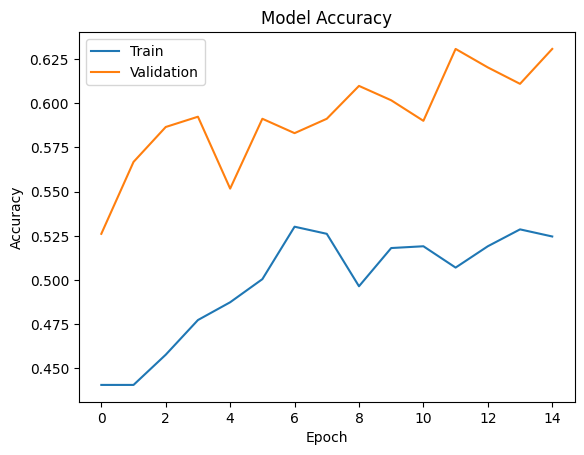

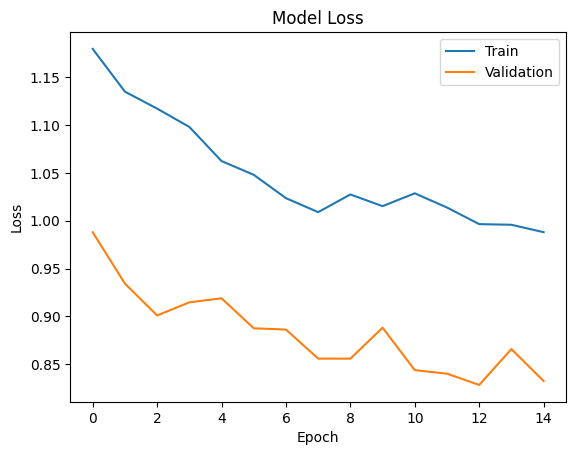

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

In [ ]:
model.save('/content/drive/MyDrive/road_damage_model_final.keras')

In [ ]:
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/road_damage_model_final.keras')

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 4 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
import os
os.listdir('/content/drive/MyDrive')

['Sakthi_Resume-25-06 (1).pdf',
 'Sakthi_Resume-25-06.pdf',
 'Sakthi Saravana phonepe project ',
 'Colab Notebooks',
 'project-4',
 'comment-toxicity-detection',
 'YouTube_Monetization_Project-3',
 'project-2',
 'Road_Damage_Project',
 'photo.jpg',
 'Pan.jpg',
 'Aadhar.jpg',
 'road_damage_model.h5',
 'road_damage_model_final.h5',
 'road_damage_model_final.keras']